# Set Configuration

In [1]:
from diffusion_hash_inv.config import MainConfig, HashConfig, MessageConfig, OutputConfig, Byte2RGBConfig
from diffusion_hash_inv.main import MainEP
from diffusion_hash_inv.utils import FileIO
from diffusion_hash_inv.main import RuntimeConfig

length = 128
iteration = 1000

main_cfg = MainConfig(
    verbose_flag=False,
    clean_flag=False,
    debug_flag=False,
    make_image_flag=False,
)
hash_cfg = HashConfig(
    hash_alg="md5",
    length=length,
)
message_cfg = MessageConfig(
    message_flag=False,
    length=length,
    random_flag=False,
    seed_flag=True,
)
output_cfg = OutputConfig()
byte2rgb_cfg = Byte2RGBConfig()
runtime_cfg = RuntimeConfig(
    main=main_cfg,
    message=message_cfg,
    hash=hash_cfg,
    output=output_cfg,
    rgb=byte2rgb_cfg,
)


io_controller = FileIO(main_config=main_cfg, output_cfg=output_cfg)

In [2]:
main = MainEP(runtime_config=runtime_cfg, file_controller=io_controller)
main.run(iteration=iteration)

Main Entry Point Initialized.
Program Start Time: 2026-04-29 16:19:25.664915+09:00
Hash Algorithm: MD5
Message Length: 128
Data Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/data
Output Directory: /Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output


Hash Generation Progress:   0%|          | 0/1000 [00:00<?, ?iteration/s]

Hash Generation Progress: 100%|██████████| 1000/1000 [00:00<00:00, 1108.63iteration/s, Hash Algorithm=MD5, Message Length=128]

Hash Calculation time: 913 ms, 455 us, 334 ns
Process completed.

Total Execution Time: 913 ms, 455 us, 334 ns



In [3]:
from diffusion_hash_inv.logger.logger import Logs

logs = Logs.get_logs(io_controller, hash_cfg, main_cfg)
print(len(logs))
print(logs[0])

1000
{'MD5_128_2026-04-29 16-19-25_0000': {'Hash Algorithm': 'MD5', 'Byte order': 'little', 'Hierarchy': ['Step', 'Round', 'Loop'], 'Length': 128, 'Message': '0x00000000000000000000000000000000', 'Logs': {'1st Step': '0x0000000000000000000000000000000080000000000000000000000000000000000000000000000000000000000000000000000000000000', '2nd Step': {'1st Block': ['0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x80000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x00000000', '0x80000000', '0x00000000']}, '3rd Step': {'A': '0x01234567', 'B': '0x89abcdef', 'C': '0xfedcba98', 'D': '0x76543210'}, '4th Step': {'1st Round': {'Loop Start': {'A': '0x01234567', 'B': '0x89abcdef', 'C': '0xfedcba98', 'D': '0x76543210'}, '1st Loop': {'A': '0x76543210', 'B': '0x74e71fa5', 'C': '0x89abcdef', 'D': '0xfedcba98'}, '2nd Loop': {'A': '0xfedcba98', 'B': '0xde529521', 'C': '0x74e71fa5', 'D': '0x89abcdef'}, '3rd Loop': {'A': '0x89

In [4]:
_logs = io_controller.get_latest_files_by_date(hash_cfg.hash_alg, hash_cfg.length)
print(_logs[0])

/Users/choisoonwook/Experiments_local/Diffusion_HASH_inverse/output/json/2026-04-29 16-19-25/MD5_128_2026-04-29 16-19-25_0000.json


In [5]:
def get_step4(logs):
    step4_logs = []
    for log in logs:
        _tmp = list(log.values())
        assert len(_tmp) == 1, "Each log dictionary should contain exactly one key-value pair."
        log_dict = list(log.values())[0]
        if "Logs" in log_dict and "4th Step" in log_dict["Logs"]:
            step4_logs.append(log_dict["Logs"]["4th Step"])
    return step4_logs

In [6]:
from typing import List, Dict, Any

step4_logs: List[Dict[str, Any]] = get_step4(logs)
print(step4_logs[0])
beta_schedule = list()

{'1st Round': {'Loop Start': {'A': '0x01234567', 'B': '0x89abcdef', 'C': '0xfedcba98', 'D': '0x76543210'}, '1st Loop': {'A': '0x76543210', 'B': '0x74e71fa5', 'C': '0x89abcdef', 'D': '0xfedcba98'}, '2nd Loop': {'A': '0xfedcba98', 'B': '0xde529521', 'C': '0x74e71fa5', 'D': '0x89abcdef'}, '3rd Loop': {'A': '0x89abcdef', 'B': '0x50abf293', 'C': '0xde529521', 'D': '0x74e71fa5'}, '4th Loop': {'A': '0x74e71fa5', 'B': '0x8075e8ce', 'C': '0x50abf293', 'D': '0xde529521'}, '5th Loop': {'A': '0xde529521', 'B': '0x1ff67517', 'C': '0x8075e8ce', 'D': '0x50abf293'}, '6th Loop': {'A': '0x50abf293', 'B': '0x1e85da10', 'C': '0x1ff67517', 'D': '0x8075e8ce'}, '7th Loop': {'A': '0x8075e8ce', 'B': '0x45badcdc', 'C': '0x1e85da10', 'D': '0x1ff67517'}, '8th Loop': {'A': '0x1ff67517', 'B': '0x78c4d484', 'C': '0x45badcdc', 'D': '0x1e85da10'}, '9th Loop': {'A': '0x1e85da10', 'B': '0x02e35c6f', 'C': '0x78c4d484', 'D': '0x45badcdc'}, '10th Loop': {'A': '0x45badcdc', 'B': '0x1106aeb4', 'C': '0x02e35c6f', 'D': '0x78c4

In [7]:
def cumulative_block(byte_list: List[bytes], block: bytes, indent: int = 0) -> List[bytes]:
    """
    Seperate Block into bytes and cumulatively add to byte_list. Return the updated byte_list.
    """
    _byte = 0
    for byte in block:
        _byte = byte if len(byte_list) == 0 else byte + byte_list[-1]
        # _byte = _byte % (0xff + 1) # Ensure byte value stays within 0-255
        if main_cfg.verbose_flag:
            # print(f"{'\t' * indent}Byte: {byte}")
            # print(f"{'\t' * (indent+1)}Cumulative Byte: {_byte}")
            pass
        byte_list.append(_byte)
    return byte_list


def make_beta_schedule(step4_logs: Dict[str, Any]) -> List[float]:
    step4_log: Dict[str, Any] = list(step4_logs.values())
    beta_schedule = []
    for log in step4_log:
        for key, value in log.items():
            if main_cfg.verbose_flag:
                # print(f"Key: {key}")
                pass
            for k, v in value.items():
                _v = Logs.str_to_bytes(v)
                if main_cfg.verbose_flag:
                    # print(f"\tKey: {k}, Value: {v}")
                    # print(f"\t\tConverted Value: {_v}")
                    pass
                cumulative_block(beta_schedule, _v, indent=3)
                
    return beta_schedule

In [8]:
from tqdm import tqdm

step4_log_process = tqdm(step4_logs, desc="Processing Step 4 Logs")
for log in step4_log_process:
    beta_schedule.append(make_beta_schedule(log))

Processing Step 4 Logs: 100%|██████████| 1000/1000 [00:00<00:00, 2388.75it/s]


In [9]:
print(len(beta_schedule))
print(len(beta_schedule[0]))
print(beta_schedule[0])
print(beta_schedule[1])

1000
1056
[1, 36, 105, 208, 345, 516, 721, 960, 1214, 1434, 1620, 1772, 1890, 1974, 2024, 2040, 2158, 2242, 2292, 2308, 2424, 2655, 2686, 2851, 2988, 3159, 3364, 3603, 3857, 4077, 4263, 4415, 4669, 4889, 5075, 5227, 5449, 5531, 5680, 5713, 5829, 6060, 6091, 6256, 6393, 6564, 6769, 7008, 7145, 7316, 7521, 7760, 7840, 8011, 8253, 8400, 8622, 8704, 8853, 8886, 9002, 9233, 9264, 9429, 9545, 9776, 9807, 9972, 10100, 10217, 10449, 10655, 10735, 10906, 11148, 11295, 11517, 11599, 11748, 11781, 12003, 12085, 12234, 12267, 12298, 12544, 12661, 12684, 12812, 12929, 13161, 13367, 13447, 13618, 13860, 14007, 14087, 14258, 14500, 14647, 14677, 14810, 15028, 15044, 15075, 15321, 15438, 15461, 15589, 15706, 15938, 16144, 16272, 16389, 16621, 16827, 16896, 17082, 17302, 17522, 17552, 17685, 17903, 17919, 17950, 18196, 18313, 18336, 18367, 18613, 18730, 18753, 18873, 19069, 19281, 19413, 19482, 19668, 19888, 20108, 20138, 20271, 20489, 20505, 20535, 20668, 20886, 20902, 20904, 21131, 21223, 21334, 2145

In [10]:
if main_cfg.verbose_flag:
    width = len(str(iteration))
    for i, beta in enumerate(beta_schedule):
        print(f"Beta Schedule {i:0{width}}:")
        print(f"{'\t' * 1}Beta: ", end="")
        for j, b in enumerate(beta):
            print(f"{b:03},", end=" ")
        print("\n")

In [11]:
import numpy as np

beta_array = np.array(beta_schedule)
print(beta_array.shape)
min = np.min(beta_array, axis=0)
max = np.max(beta_array, axis=0)
mean = np.mean(beta_array, axis=0)
var = np.var(beta_array, axis=0)
std = np.std(beta_array, axis=0)

np.set_printoptions(threshold=np.inf, linewidth=np.inf)

print(f"Min: {min}, Length: {len(min)}")
print(f"Max: {max}, Length: {len(max)}")
print(f"Mean: {mean}, Length: {len(mean)}")
print(f"Variance: {var}, Length: {len(var)}")
print(f"Standard Deviation: {std}, Length: {len(std)}")

(1000, 1056)
Min: [     1     36    105    208    345    516    721    960   1214   1434   1620   1772   1890   1974   2024   2040   2158   2242   2292   2308   2424   2424   2456   2621   2758   2929   3134   3373   3627   3847   4033   4185   4439   4659   4845   4997   5218   5325   5434   5439   5555   5559   5592   5757   5894   6065   6270   6509   6646   6817   7022   7261   7337   7507   7608   7768   7989   8056   8223   8227   8343   8381   8414   8579   8695   8695   8728   8893   8977   9079   9253   9373   9427   9625   9700   9823  10044  10188  10354  10357  10519  10574  10773  10777  10839  11038  11074  11108  11192  11299  11525  11578  11616  11795  11829  11837  11876  11994  12028  12036  12185  12422  12677  12723  12785  12984  13138  13172  13256  13363  13493  13584  13627  13733  13742  13784  13822  13890  14103  14154  14393  14393  14571  14646  14775  14881  14936  15017  15024  15078  15176  15183  15408  15473  15619  15828  15866  15934  16147  16198  

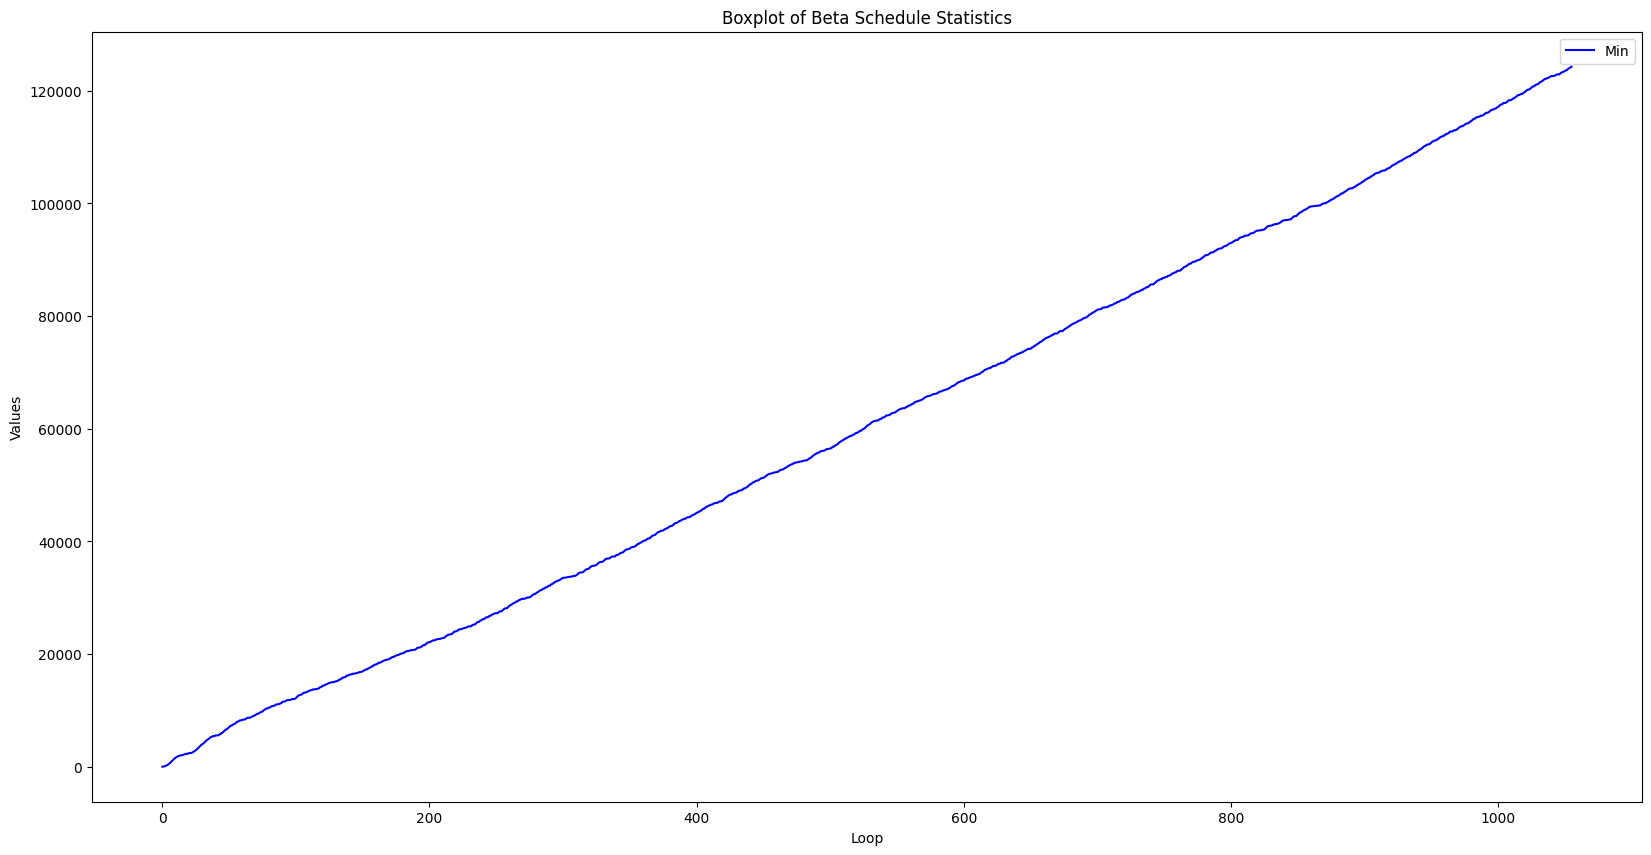

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
plt.plot(min, label='Min', color='blue')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

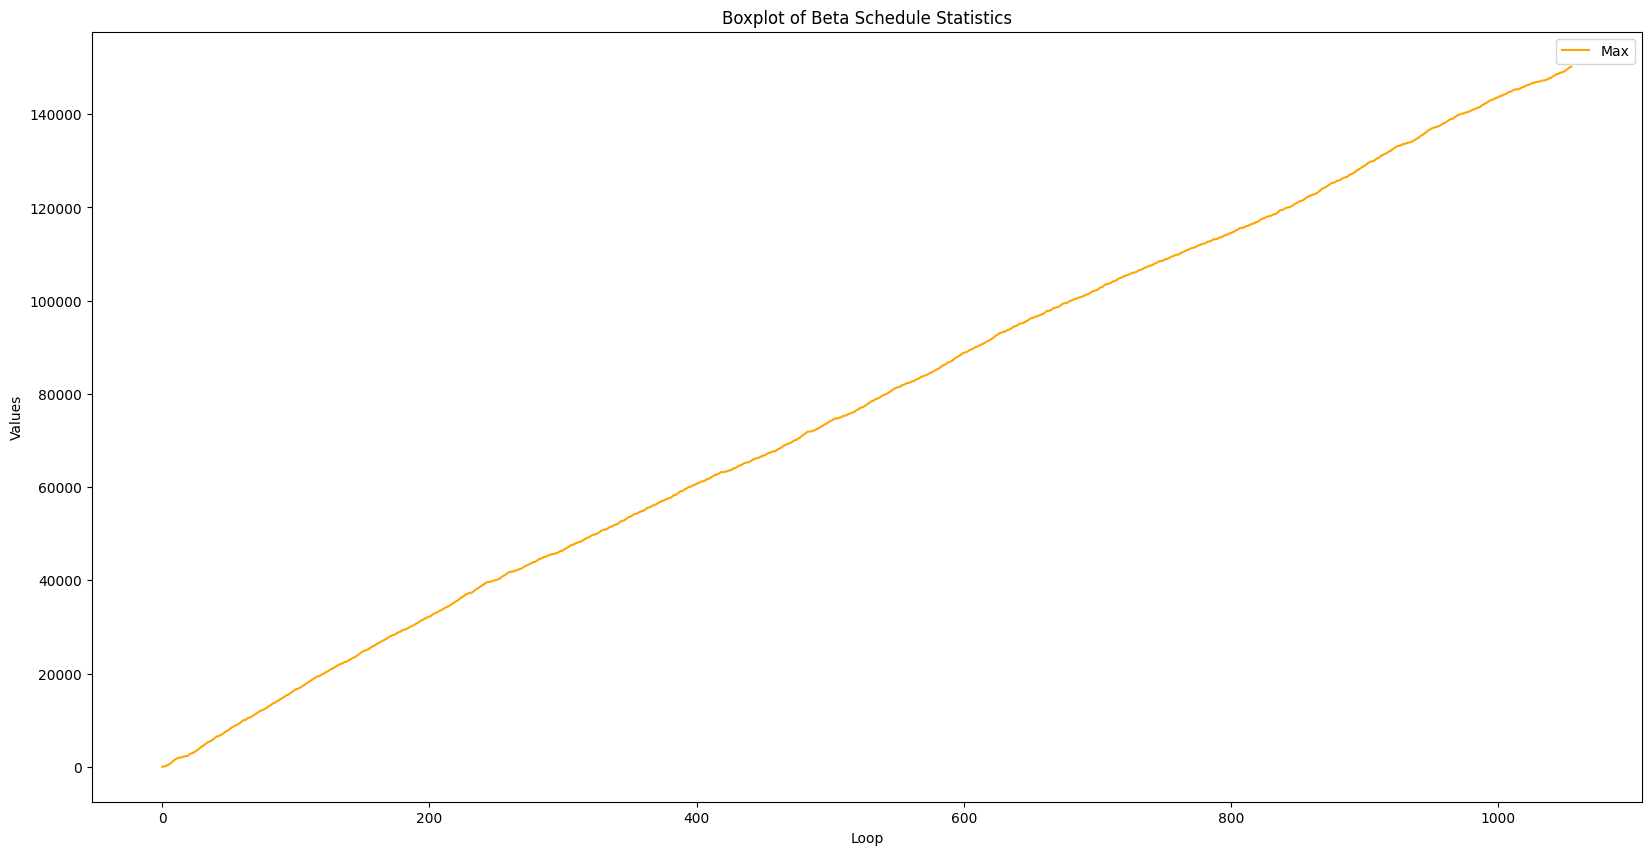

In [13]:
plt.figure(figsize=(20, 10))
plt.plot(max, label='Max', color='orange')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

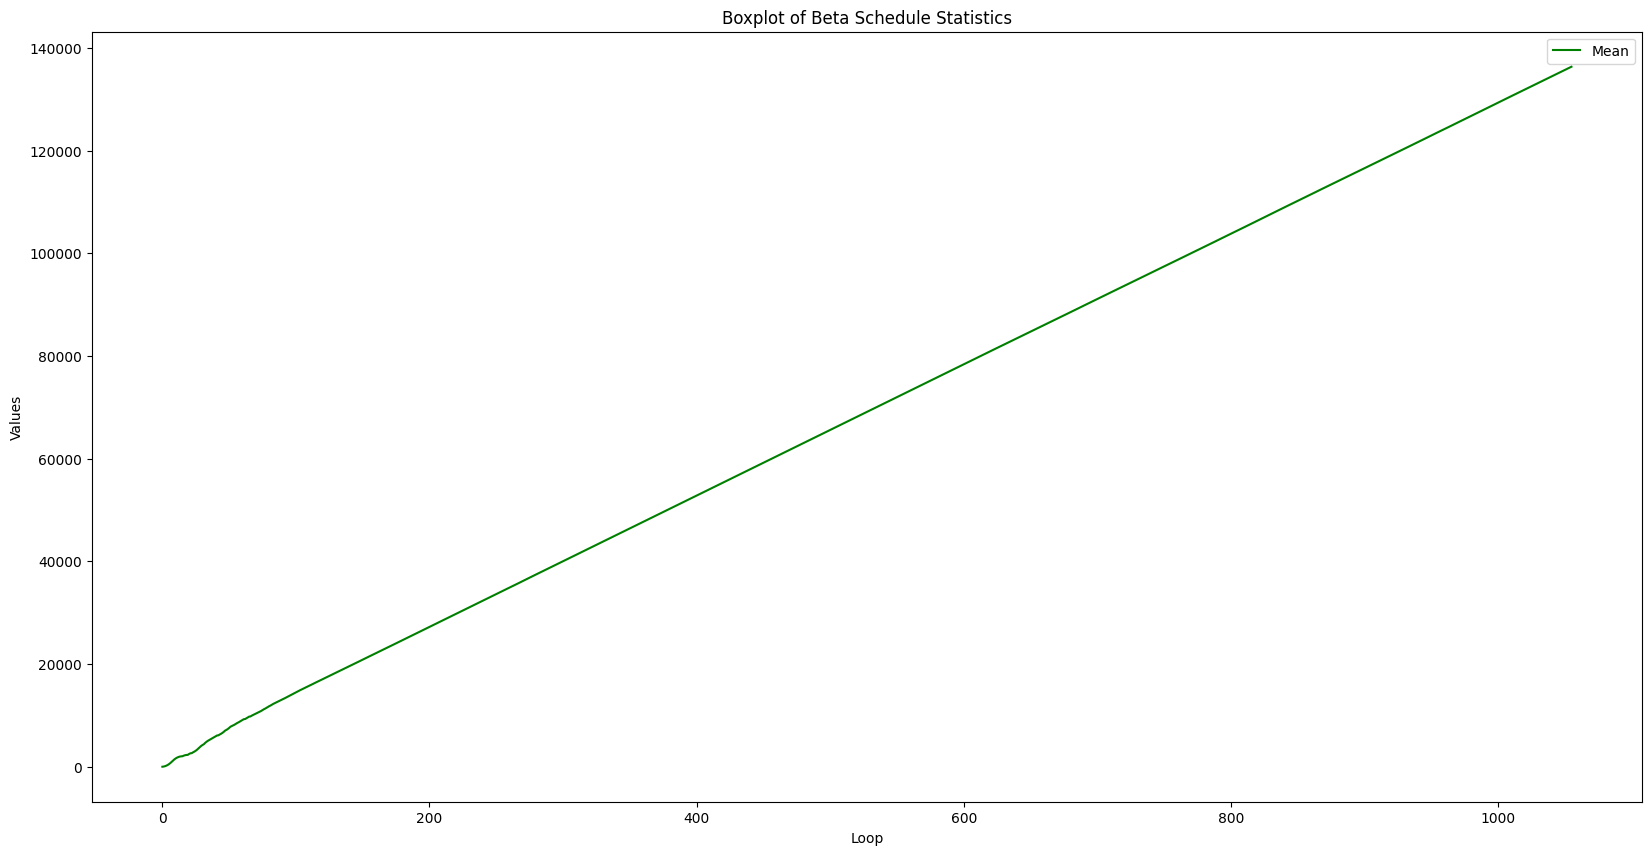

In [14]:
plt.figure(figsize=(20, 10))
plt.plot(mean, label='Mean', color='green')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

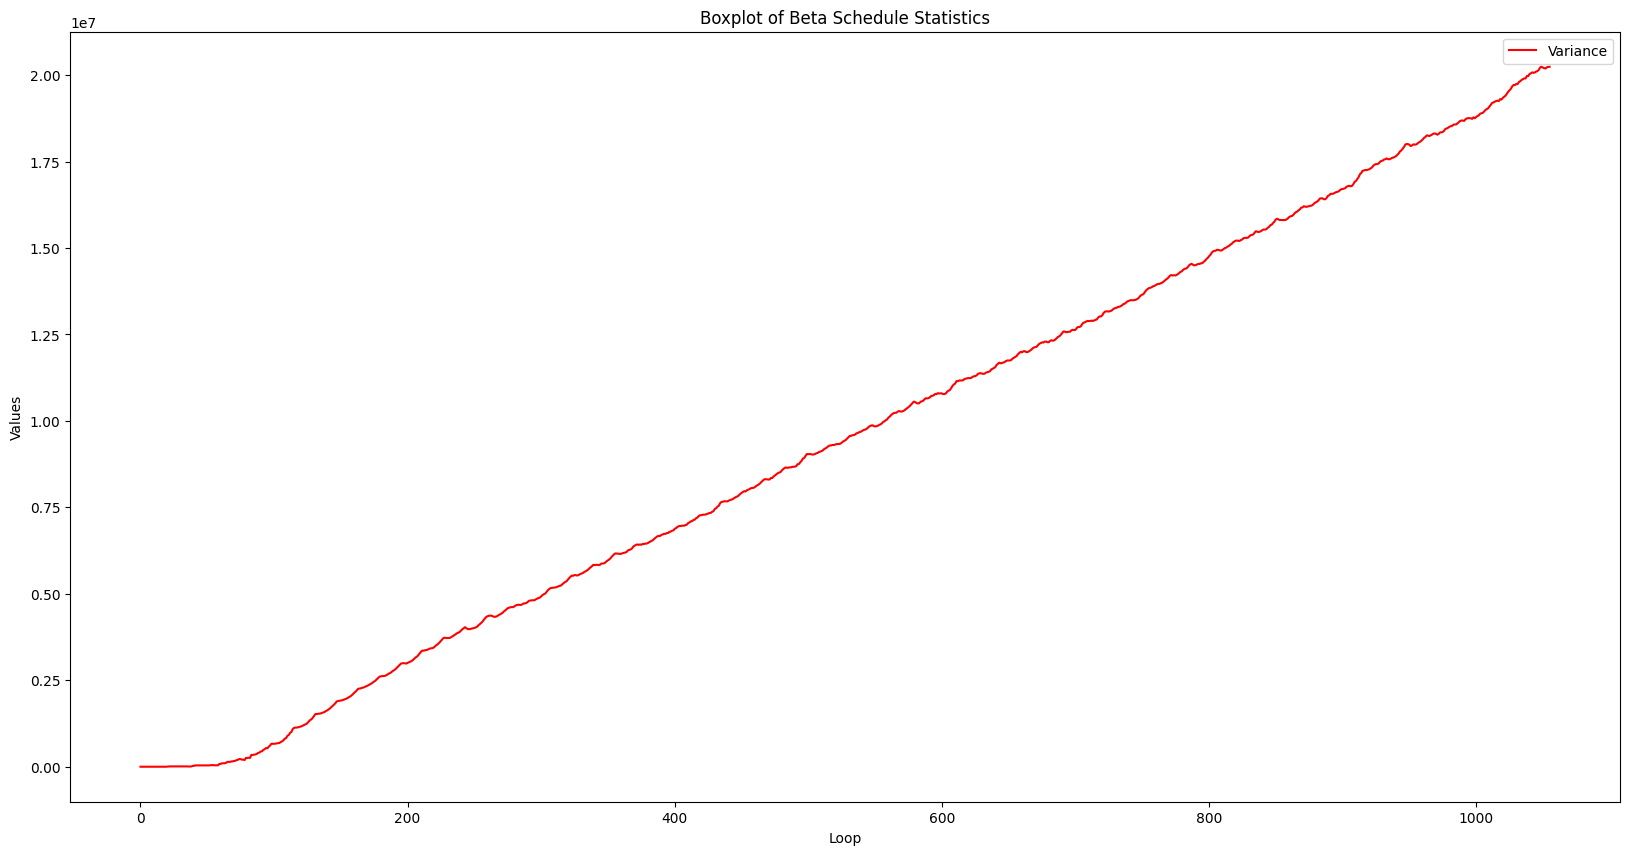

In [15]:
plt.figure(figsize=(20, 10))
plt.plot(var, label='Variance', color='red')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

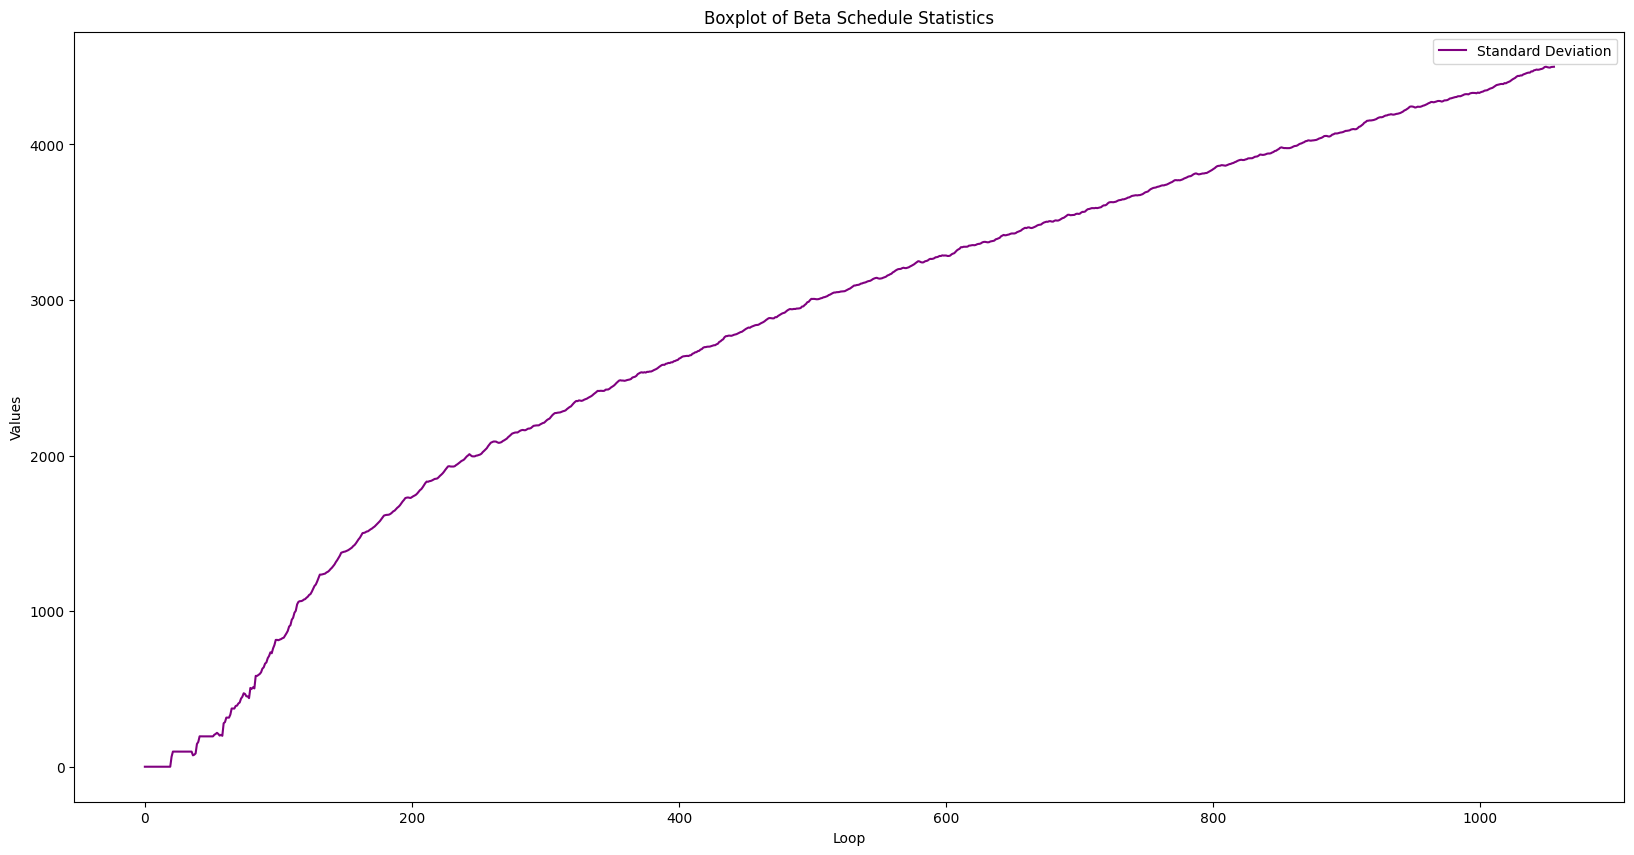

In [16]:
plt.figure(figsize=(20, 10))
plt.plot(std, label='Standard Deviation', color='purple')
plt.legend()
plt.title('Boxplot of Beta Schedule Statistics')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

In [17]:
import mlx.core as mx
betas = mx.linspace(start=1e-4, stop=2e-2, num=len(beta_schedule[0]))
betas = np.array(betas, dtype=np.float64)
print(betas)
print(beta_schedule[0])
candidate_betas = np.multiply(beta_schedule[0], betas)
candidate_betas = np.array(candidate_betas, dtype=np.float64)
print(candidate_betas)

str_max = 0
for i in range(0, len(beta_schedule)):
    str_len = len(str(beta_schedule[i]))
    if str_len > str_max:
        str_max = str_len
print(f"Max String Length: {str_max}")

[9.99999975e-05 1.18862554e-04 1.37725117e-04 1.56587674e-04 1.75450230e-04 1.94312801e-04 2.13175343e-04 2.32037914e-04 2.50900455e-04 2.69763026e-04 2.88625597e-04 3.07488139e-04 3.26350681e-04 3.45213281e-04 3.64075822e-04 3.82938364e-04 4.01800935e-04 4.20663477e-04 4.39526048e-04 4.58388618e-04 4.77251189e-04 4.96113731e-04 5.14976273e-04 5.33838873e-04 5.52701415e-04 5.71563956e-04 5.90426556e-04 6.09289040e-04 6.28151640e-04 6.47014240e-04 6.65876723e-04 6.84739323e-04 7.03601865e-04 7.22464407e-04 7.41326949e-04 7.60189607e-04 7.79052149e-04 7.97914632e-04 8.16777232e-04 8.35639716e-04 8.54502374e-04 8.73364974e-04 8.92227457e-04 9.11090057e-04 9.29952541e-04 9.48815199e-04 9.67677683e-04 9.86540224e-04 1.00540277e-03 1.02426542e-03 1.04312797e-03 1.06199051e-03 1.08085305e-03 1.09971559e-03 1.11857813e-03 1.13744067e-03 1.15630333e-03 1.17516587e-03 1.19402842e-03 1.21289096e-03 1.23175350e-03 1.25061604e-03 1.26947858e-03 1.28834124e-03 1.30720378e-03 1.32606633e-03 1.3449287

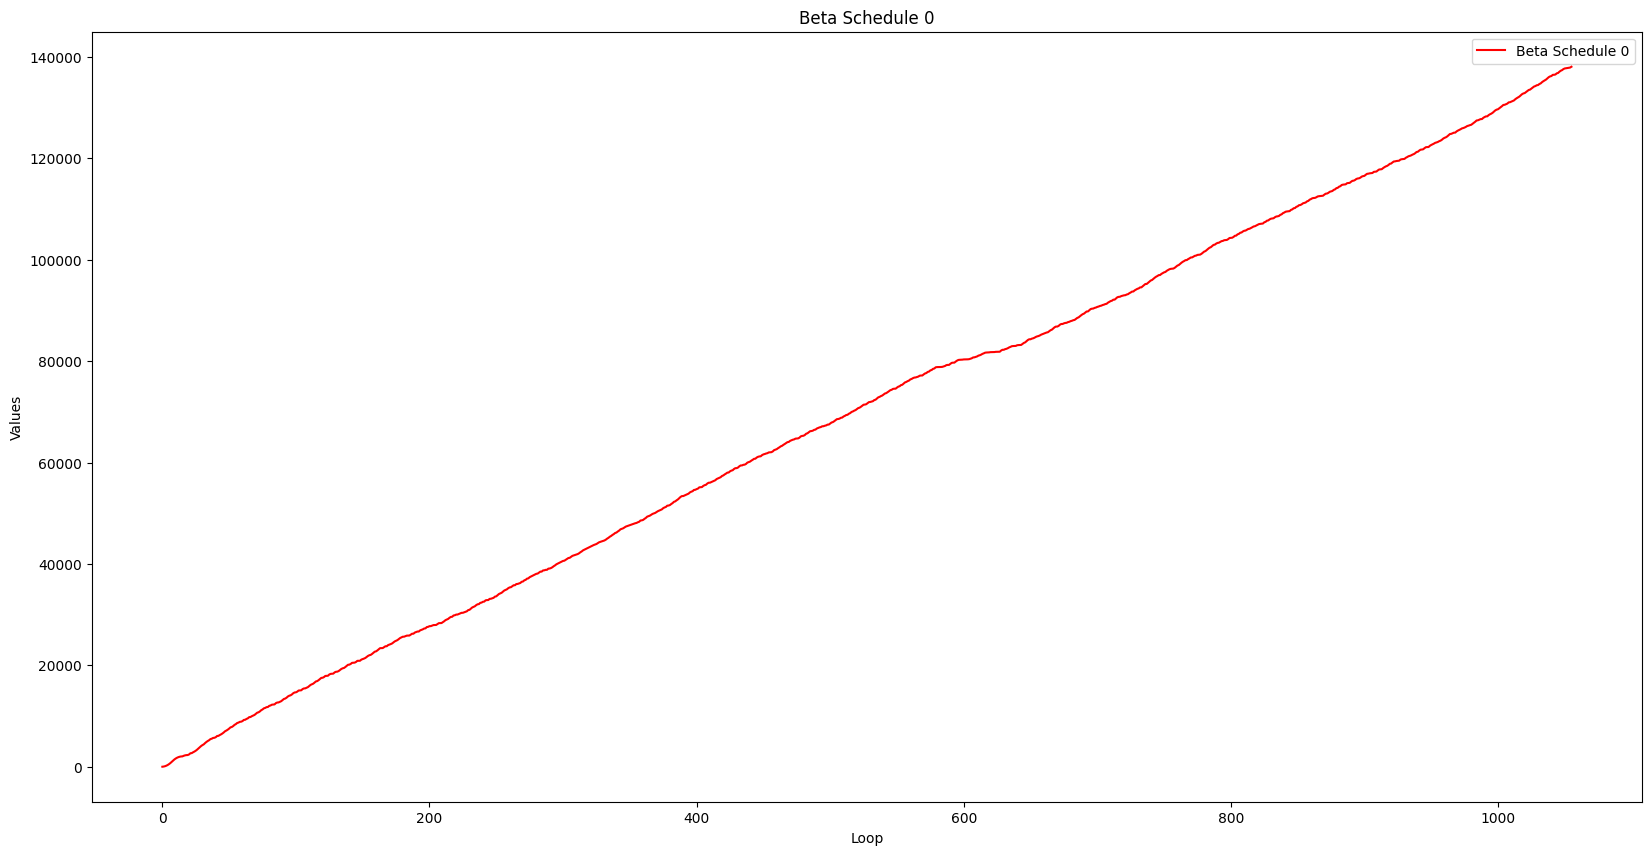

In [18]:
plt.figure(figsize=(20, 10))
plt.plot(beta_schedule[0], label='Beta Schedule 0', color='red')
plt.legend()
plt.title('Beta Schedule 0')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

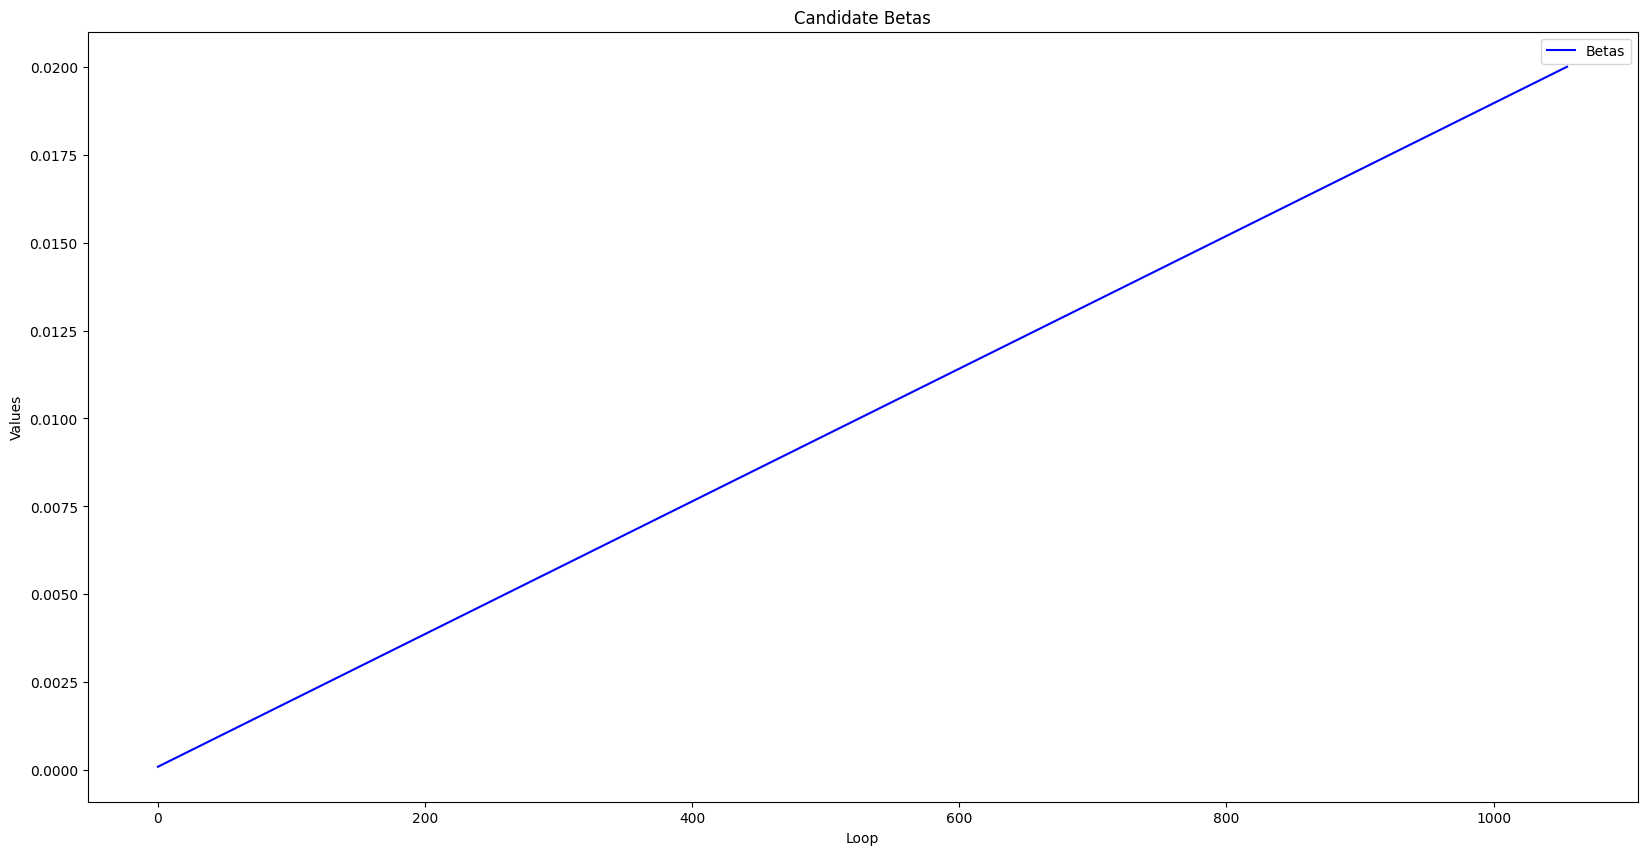

In [19]:
plt.figure(figsize=(20, 10))
plt.plot(betas, label='Betas', color='blue')
plt.legend()
plt.title('Candidate Betas')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()

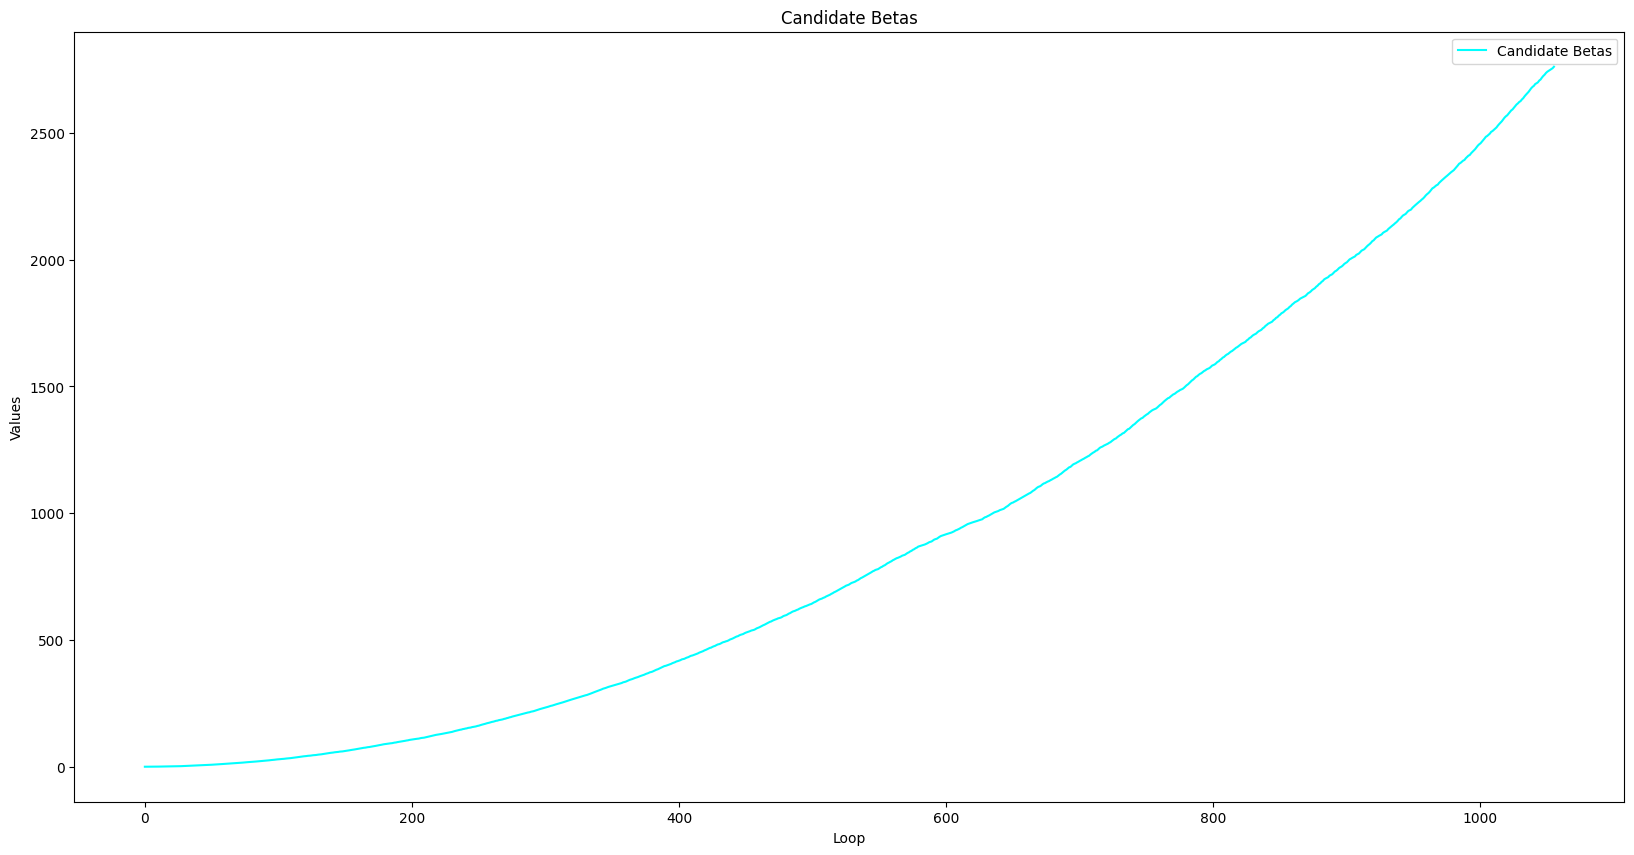

In [20]:
plt.figure(figsize=(20, 10))
plt.plot(candidate_betas, label='Candidate Betas', color='cyan')
plt.legend()
plt.title('Candidate Betas')
plt.xlabel('Loop')
plt.ylabel('Values')
plt.show()